data preparation

In [197]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


In [198]:
df1=pd.read_csv('fear_greed_index.csv')
df2=pd.read_csv('historical_data.csv')


In [199]:
df1.shape


(2644, 4)

In [200]:
df2.shape

(211224, 16)

In [201]:
df1.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [202]:
df2.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [ ]:
# counting the duplicates
duplicate_count=df1.duplicated().sum()
print("Number of duplicate rows in df1:", duplicate_count)

duplicate_count=df2.duplicated().sum()
print("Number of duplicate rows in df2:", duplicate_count)



Number of duplicate rows in df1: 0
Number of duplicate rows in df2: 0


In [204]:


df1['timestamp'] = pd.to_datetime(df1['timestamp'], unit='s', utc=True, errors='coerce')


df2['Timestamp'] = pd.to_datetime(df2['Timestamp'], unit='ms', utc=True, errors='coerce')


df1['date'] = df1['timestamp'].dt.date
df2['date'] = df2['Timestamp'].dt.date

df1_daily = df1.groupby('date').agg({
    'value': 'last',
    'classification': 'last'
}).reset_index()


df2_daily = df2.groupby('date').agg({
    'Execution Price': ['first', 'max', 'min', 'last'],  # pseudo-OHLC
    'Size USD': 'sum',                                  # total volume
    'Closed PnL': 'sum'                                 # profitability signal
})


df2_daily.columns = ['open', 'high', 'low', 'close', 'volume', 'daily_pnl']
df2_daily = df2_daily.reset_index()



merged_data = pd.merge(df1_daily, df2_daily, on='date', how='inner')

merged_data = merged_data.sort_values('date').reset_index(drop=True)

merged_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            6 non-null      object 
 1   value           6 non-null      int64  
 2   classification  6 non-null      object 
 3   open            6 non-null      float64
 4   high            6 non-null      float64
 5   low             6 non-null      float64
 6   close           6 non-null      float64
 7   volume          6 non-null      float64
 8   daily_pnl       6 non-null      float64
dtypes: float64(6), int64(1), object(2)
memory usage: 564.0+ bytes


creating daily pnl column

In [205]:
df2['Closed PnL'] = pd.to_numeric(df2['Closed PnL'], errors='coerce')
df2['Size USD'] = pd.to_numeric(df2['Size USD'], errors='coerce')

daily_pnl = df2.groupby('date')['Closed PnL'].sum().rename('daily_pnl')



creating win rate

In [206]:
win_rate = df2.groupby('date').apply(
    lambda x: (x['Closed PnL'] > 0).mean()
).rename('win_rate')



C:\Users\snigdha singh\AppData\Local\Temp\ipykernel_21652\4019069863.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rate = df2.groupby('date').apply(


In [207]:
drawdown_proxy = df2.groupby('date')['Closed PnL'].apply(
    lambda x: x[x < 0].sum()
).rename('drawdown_proxy')



average trade and number of trades per day

In [208]:
avg_trade_size = df2.groupby('date')['Size USD'].mean().rename('avg_trade_size')
trade_count = df2.groupby('date').size().rename('trade_count')

long short ratio

In [209]:
df2['Side'] = df2['Side'].str.lower()

long_short_ratio = df2.groupby('date').apply(
    lambda x: (x['Side'].eq('buy').sum()) / (x['Side'].eq('sell').sum() + 1e-6)
).rename('long_short_ratio')

C:\Users\snigdha singh\AppData\Local\Temp\ipykernel_21652\785243344.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  long_short_ratio = df2.groupby('date').apply(


In [210]:
leverage_proxy = df2.groupby('date')['Size USD'].median().rename('median_trade_size')

metrics_df = pd.concat([
    daily_pnl,
    win_rate,
    avg_trade_size,
    trade_count,
    long_short_ratio,
    leverage_proxy
], axis=1).reset_index()


In [211]:
final_df = pd.merge(merged_data, metrics_df, on='date', how='inner')
print(final_df.head())
print(final_df.describe())

         date  value classification        open      high          low  \
0  2023-03-28     59          Greed  1897.90000    1898.6  1897.900000   
1  2023-11-14     69          Greed  2230.10000   47063.0     0.084411   
2  2024-03-09     84  Extreme Greed     0.13097   70669.0     0.000895   
3  2024-07-03     50        Neutral     2.18000   71764.0     0.000010   
4  2024-10-27     74          Greed     7.97690  107320.0     0.000005   

          close        volume   daily_pnl_x   daily_pnl_y  win_rate  \
0   1898.600000  4.770000e+02  0.000000e+00  0.000000e+00  0.000000   
1  46134.000000  1.155543e+07  1.555034e+02  1.555034e+02  0.274641   
2      0.066971  3.940677e+07  1.769655e+05  1.769655e+05  0.490089   
3    151.760000  2.184323e+07  1.587424e+05  1.587424e+05  0.317182   
4   3297.000000  1.039478e+08  3.189461e+06  3.189461e+06  0.451605   

   avg_trade_size  trade_count  long_short_ratio  median_trade_size  
0      159.000000            3      3.000000e+06          

In [212]:
fear_df = final_df[final_df['classification'].str.contains('fear', na=False)]
greed_df = final_df[final_df['classification'].str.contains('greed', na=False)]


In [213]:
print(final_df.columns)

Index(['date', 'value', 'classification', 'open', 'high', 'low', 'close',
       'volume', 'daily_pnl_x', 'daily_pnl_y', 'win_rate', 'avg_trade_size',
       'trade_count', 'long_short_ratio', 'median_trade_size'],
      dtype='object')


C:\Users\snigdha singh\AppData\Local\Temp\ipykernel_21652\3991761736.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


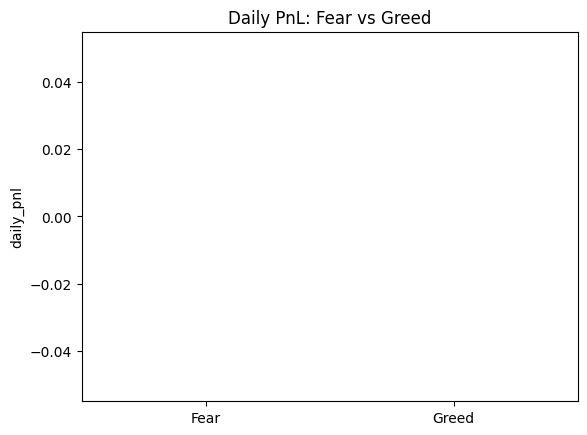

In [214]:

plt.figure()
plt.boxplot([
    fear_df['daily_pnl_x'].dropna(),
    greed_df['daily_pnl_x'].dropna()
], labels=['Fear', 'Greed'])

plt.title("Daily PnL: Fear vs Greed")
plt.ylabel("daily_pnl")
plt.show()

C:\Users\snigdha singh\AppData\Local\Temp\ipykernel_21652\847276908.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


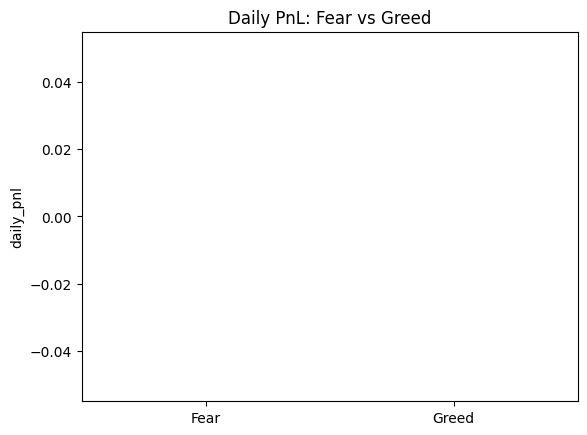

In [217]:
plt.figure()
plt.boxplot([
    fear_df['daily_pnl_y'].dropna(),
    greed_df['daily_pnl_y'].dropna()
], labels=['Fear', 'Greed'])

plt.title("Daily PnL: Fear vs Greed")
plt.ylabel("daily_pnl")
plt.show()

no relation between value(fear and greed) and daily pnl

C:\Users\snigdha singh\AppData\Local\Temp\ipykernel_21652\1905187365.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


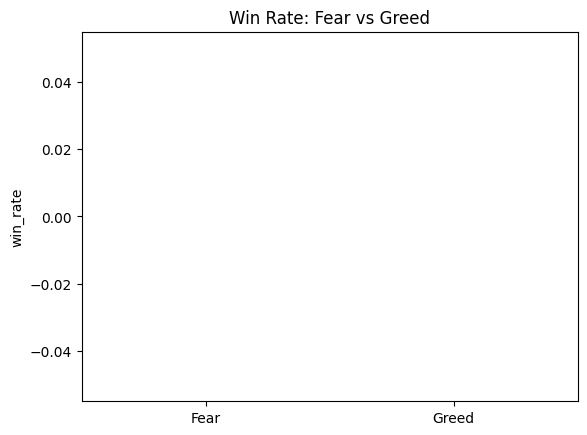

In [218]:
plt.figure()
plt.boxplot([
    fear_df['win_rate'].dropna(),
    greed_df['win_rate'].dropna()
], labels=['Fear', 'Greed'])

plt.title("Win Rate: Fear vs Greed")
plt.ylabel("win_rate")
plt.show()

no relation between winrate and fear and greed

In [219]:
plt.figure()
plt.boxplot([
    fear_df['drawdown_proxy'].dropna(),
    greed_df['drawdown_proxy'].dropna()
], labels=['Fear', 'Greed'])

plt.title("Drawdown Proxy: Fear vs Greed")
plt.ylabel("drawdown_proxy")
plt.show()

KeyError: 'drawdown_proxy'

<Figure size 640x480 with 0 Axes>

In [ ]:
final_df.columns

Index(['date', 'value', 'classification', 'open', 'high', 'low', 'close',
       'volume', 'daily_pnl_x', 'daily_pnl_y', 'win_rate', 'avg_trade_size',
       'trade_count', 'long_short_ratio', 'median_trade_size'],
      dtype='object')

integrating drawdown_proxy to the final df

In [ ]:

final_df = pd.merge(final_df, drawdown_proxy, on='date', how='left')

final_df['drawdown_proxy'] = final_df['drawdown_proxy'].fillna(0)

print(final_df.columns)


Index(['date', 'value', 'classification', 'open', 'high', 'low', 'close',
       'volume', 'daily_pnl_x', 'daily_pnl_y', 'win_rate', 'avg_trade_size',
       'trade_count', 'long_short_ratio', 'median_trade_size',
       'drawdown_proxy'],
      dtype='object')


C:\Users\snigdha singh\AppData\Local\Temp\ipykernel_21652\3232014865.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


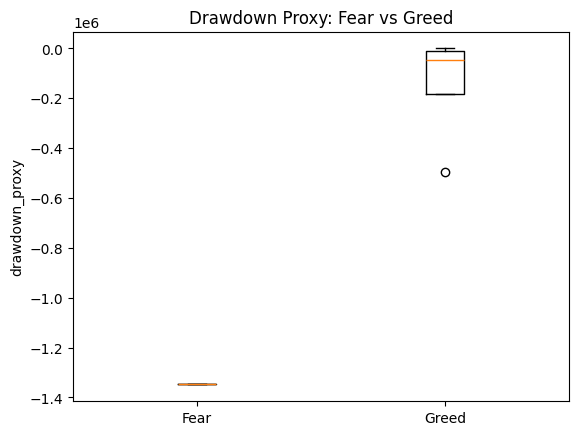

In [ ]:


final_df['classification'] = final_df['classification'].str.lower()

fear_df = final_df[final_df['classification'].str.contains('fear', na=False)]
greed_df = final_df[final_df['classification'].str.contains('greed', na=False)]


plt.figure()
plt.boxplot([
    fear_df['drawdown_proxy'],
    greed_df['drawdown_proxy']
], labels=['Fear', 'Greed'])

plt.title("Drawdown Proxy: Fear vs Greed")
plt.ylabel("drawdown_proxy")
plt.show()

In [ ]:

df2['Size USD'] = pd.to_numeric(df2['Size USD'], errors='coerce')


df2['Side'] = df2['Side'].str.lower()


num_trades = df2.groupby('date').size().rename('num_trades')


avg_trade_size = df2.groupby('date')['Size USD'].mean().rename('avg_trade_size')


median_trade_size = df2.groupby('date')['Size USD'].median().rename('median_trade_size')


behavior_df = pd.concat([
    num_trades,
    avg_trade_size,
    median_trade_size,
    long_short_ratio
], axis=1).reset_index()

final_df = pd.merge(final_df, behavior_df, on='date', how='inner')

print(final_df.columns)

Index(['date', 'value', 'classification', 'open', 'high', 'low', 'close',
       'volume', 'daily_pnl_x', 'daily_pnl_y', 'win_rate', 'avg_trade_size_x',
       'trade_count', 'long_short_ratio_x', 'median_trade_size_x',
       'drawdown_proxy', 'num_trades', 'avg_trade_size_y',
       'median_trade_size_y', 'long_short_ratio_y'],
      dtype='object')


C:\Users\snigdha singh\AppData\Local\Temp\ipykernel_21652\3366386803.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


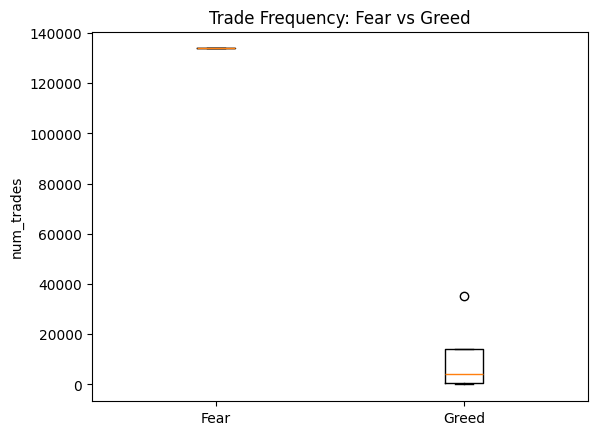

In [ ]:


plt.figure()
plt.boxplot([
    fear_df['num_trades'],
    greed_df['num_trades']
], labels=['Fear', 'Greed'])

plt.title("Trade Frequency: Fear vs Greed")
plt.ylabel("num_trades")
plt.show()

In [ ]:
print(final_df[['date']].head())
print(behavior_df[['date']].head())

         date
0  2023-03-28
1  2023-11-14
2  2024-03-09
3  2024-07-03
4  2024-10-27
         date
0  2023-03-28
1  2023-11-14
2  2024-03-09
3  2024-07-03
4  2024-10-27


In [ ]:
final_df['date'] = pd.to_datetime(final_df['date'])
behavior_df['date'] = pd.to_datetime(behavior_df['date'])

In [ ]:
final_df['classification'] = final_df['classification'].str.lower()

fear_df = final_df[final_df['classification'].str.contains('fear', na=False)]
greed_df = final_df[final_df['classification'].str.contains('greed', na=False)]

C:\Users\snigdha singh\AppData\Local\Temp\ipykernel_21652\2332236364.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


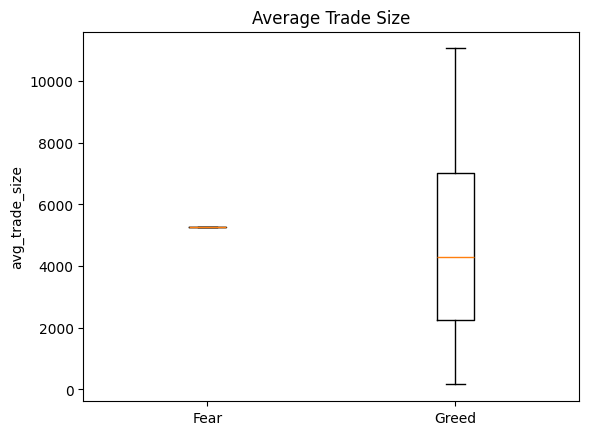

In [ ]:
plt.figure()
plt.boxplot([
    fear_df['avg_trade_size'].dropna(),
    greed_df['avg_trade_size'].dropna()
], labels=['Fear', 'Greed'])

plt.title("Average Trade Size")
plt.ylabel("avg_trade_size")
plt.show()

average trade size for fear has low variance and for greed high variance is spread between 0 to above 10,000 and median liesbetween 4000 and 6000

C:\Users\snigdha singh\AppData\Local\Temp\ipykernel_21652\265762384.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


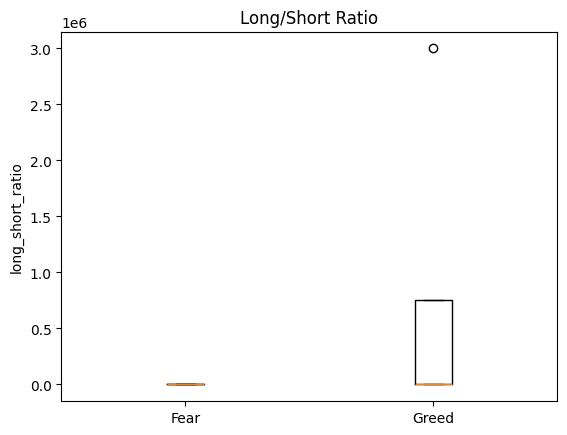

In [ ]:
plt.figure()
plt.boxplot([
    fear_df['long_short_ratio'].dropna(),
    greed_df['long_short_ratio'].dropna()
], labels=['Fear', 'Greed'])

plt.title("Long/Short Ratio")
plt.ylabel("long_short_ratio")
plt.show()

 greed has an extreme outlier skewness and heavy tailed distribution

fear has high consistency, thus most of the trade is due to fear whereas greed has fewer trades but larger ones 

In [ ]:
print(final_df.columns)

Index(['date', 'value', 'classification', 'open', 'high', 'low', 'close',
       'volume', 'daily_pnl_x', 'daily_pnl_y', 'win_rate', 'avg_trade_size',
       'trade_count', 'long_short_ratio', 'median_trade_size'],
      dtype='object')


In [ ]:
# Create trade count per day
num_trades_df = df2.groupby('date').size().reset_index(name='num_trades')

print(num_trades_df.head())

         date  num_trades
0  2023-03-28           3
1  2023-11-14        1045
2  2024-03-09        6962
3  2024-07-03        7141
4  2024-10-27       35241


In [ ]:
# Ensure same datatype
final_df['date'] = pd.to_datetime(final_df['date'])
num_trades_df['date'] = pd.to_datetime(num_trades_df['date'])

In [ ]:
final_df = pd.merge(final_df, num_trades_df, on='date', how='left')

print(final_df.columns)

Index(['date', 'value', 'classification', 'open', 'high', 'low', 'close',
       'volume', 'daily_pnl_x', 'daily_pnl_y', 'win_rate', 'avg_trade_size',
       'trade_count', 'long_short_ratio', 'median_trade_size', 'num_trades'],
      dtype='object')


In [ ]:
trade_threshold = final_df['num_trades'].median()

In [ ]:

median_size_threshold = final_df['median_trade_size'].median()

final_df['leverage_segment'] = final_df['median_trade_size'].apply(
    lambda x: 'High Leverage' if x > median_size_threshold else 'Low Leverage'
)

trade_threshold = final_df['num_trades'].median()

final_df['frequency_segment'] = final_df['num_trades'].apply(
    lambda x: 'High Frequency' if x > trade_threshold else 'Low Frequency'
)




final_df['daily_pnl'] = final_df['daily_pnl_x']  # or _y (verify later!)

winrate_threshold = final_df['win_rate'].median()

final_df['consistency_segment'] = final_df.apply(
    lambda x: 'Consistent' if (x['win_rate'] > winrate_threshold and x['daily_pnl'] > 0)
    else 'Inconsistent',
    axis=1
)


print(final_df[['leverage_segment', 'frequency_segment', 'consistency_segment']].head())

  leverage_segment frequency_segment consistency_segment
0     Low Leverage     Low Frequency        Inconsistent
1    High Leverage     Low Frequency        Inconsistent
2    High Leverage     Low Frequency          Consistent
3     Low Leverage    High Frequency        Inconsistent
4     Low Leverage    High Frequency          Consistent


In [ ]:
print((final_df['daily_pnl_x'] - final_df['daily_pnl_y']).abs().sum())

0.0


In [ ]:

final_df['pnl_volatility'] = final_df['daily_pnl'].rolling(3).std()

final_df['consistency_segment'] = final_df['pnl_volatility'].apply(
    lambda x: 'Consistent' if x < final_df['pnl_volatility'].median()
    else 'Inconsistent'
)

In [ ]:



print(pd.crosstab(final_df['classification'], final_df['leverage_segment'], normalize='index'))


print(pd.crosstab(final_df['classification'], final_df['frequency_segment'], normalize='index'))


print(pd.crosstab(final_df['classification'], final_df['consistency_segment'], normalize='index'))

leverage_segment  High Leverage  Low Leverage
classification                               
Extreme Greed          1.000000      0.000000
Fear                   1.000000      0.000000
Greed                  0.333333      0.666667
Neutral                0.000000      1.000000
frequency_segment  High Frequency  Low Frequency
classification                                  
Extreme Greed            0.000000       1.000000
Fear                     1.000000       0.000000
Greed                    0.333333       0.666667
Neutral                  1.000000       0.000000
consistency_segment  Consistent  Inconsistent
classification                               
Extreme Greed               1.0           0.0
Fear                        0.0           1.0
Greed                       0.0           1.0
Neutral                     1.0           0.0


In [ ]:
import pandas as pd

leverage_table = pd.crosstab(
    final_df['classification'],
    final_df['leverage_segment'],
    normalize='index'
)

print(leverage_table)

leverage_segment  High Leverage  Low Leverage
classification                               
Extreme Greed          1.000000      0.000000
Fear                   1.000000      0.000000
Greed                  0.333333      0.666667
Neutral                0.000000      1.000000


<Axes: title={'center': 'Leverage vs Sentiment'}, xlabel='classification'>

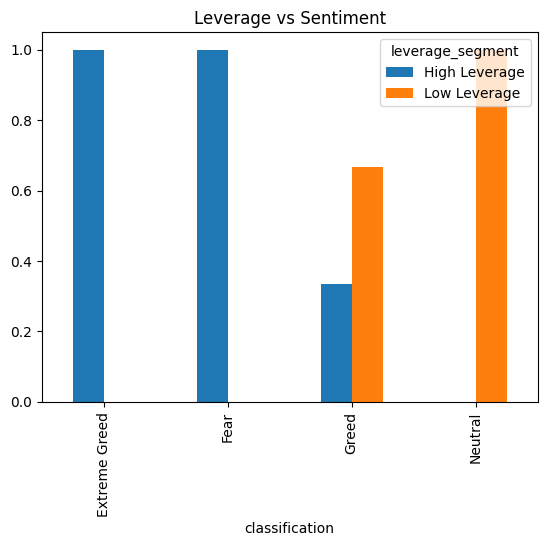

In [ ]:
leverage_table.plot(kind='bar', title="Leverage vs Sentiment")

* traders take maximum leverage showing aggressive, risk seeking behaviour a
* despite fear leverage remains high showing panic driven trades
* traders lean towards lower leverage reflecting moderate caution


In [ ]:
freq_table = pd.crosstab(
    final_df['classification'],
    final_df['frequency_segment'],
    normalize='index'
)

print(freq_table)

frequency_segment  High Frequency  Low Frequency
classification                                  
Extreme Greed            0.000000       1.000000
Fear                     1.000000       0.000000
Greed                    0.333333       0.666667
Neutral                  1.000000       0.000000


<Axes: title={'center': 'Trading Frequency vs Sentiment'}, xlabel='classification'>

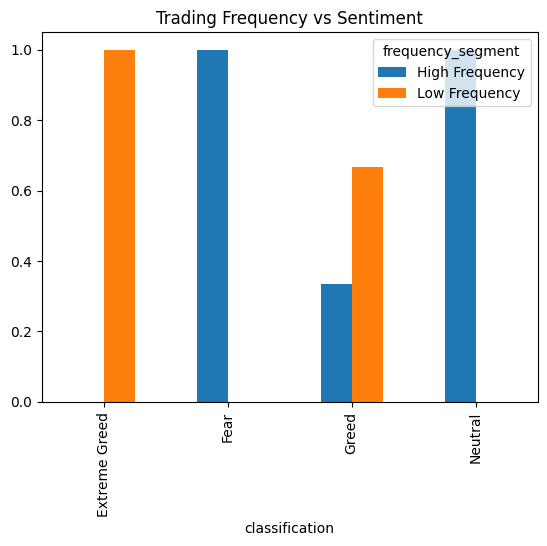

In [ ]:
freq_table.plot(kind='bar', title="Trading Frequency vs Sentiment")

* extreme greed shows low participation
* trading activity is very frequent reflecting high volume under fear
* greed has both frequencies present 
* there is consistent participation in neutral

consistency_segment  Consistent  Inconsistent
classification                               
Extreme Greed               1.0           0.0
Fear                        0.0           1.0
Greed                       0.0           1.0
Neutral                     1.0           0.0


<Axes: title={'center': 'Consistency vs Sentiment'}, xlabel='classification'>

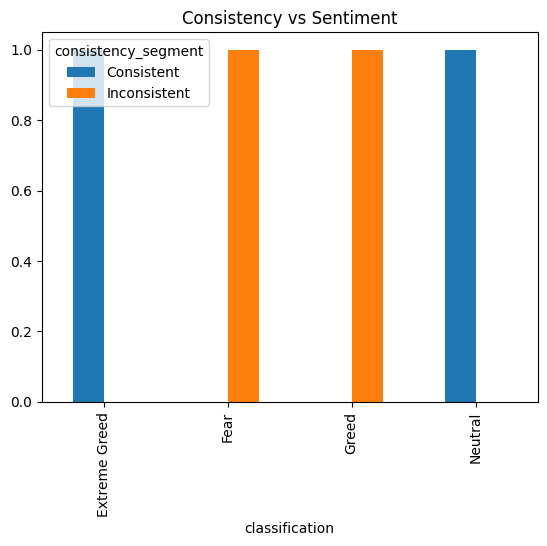

In [ ]:
consistency_table = pd.crosstab(
    final_df['classification'],
    final_df['consistency_segment'],
    normalize='index'
)

print(consistency_table)

consistency_table.plot(kind='bar', title="Consistency vs Sentiment")


more inconsistent trading in fear it means that emotional trading

observation:Fear is linked to high trade frequency and high leverage, but with low variance in trade size.

strategy: permit high_frequency trades for liquidity-focused segments, since activity is consistent and variance is low

observation: greed shows low trade frequency, high variance in trade size, and mixed leverage behavior.

Strategy:
1 Encourage selective, low-frequency trades to avoid noise.
2 Cap trade size variance by setting thresholds or risk limits, since outliers dominate.


In [222]:

final_df = final_df.sort_values('date').reset_index(drop=True)


final_df['daily_pnl'] = final_df['daily_pnl_x']


final_df['next_day_pnl'] = final_df['daily_pnl'].shift(-1)


final_df['target'] = final_df['next_day_pnl'].apply(
    lambda x: 1 if x > 0 else 0
)

In [226]:
print(final_df.columns)

Index(['date', 'value', 'classification', 'open', 'high', 'low', 'close',
       'volume', 'daily_pnl_x', 'daily_pnl_y', 'win_rate', 'avg_trade_size',
       'trade_count', 'long_short_ratio', 'median_trade_size', 'daily_pnl',
       'next_day_pnl', 'target'],
      dtype='object')


In [227]:
features = [
    'value',                 
    'trade_count',           
    'avg_trade_size',
    'median_trade_size',
    'long_short_ratio',
    'win_rate'
]


assert 'target' in final_df.columns, "target column missing!"

model_df = final_df[features + ['target']].dropna()

print(model_df.head())

   value  trade_count  avg_trade_size  median_trade_size  long_short_ratio  \
0     59            3      159.000000            156.390      3.000000e+06   
1     69         1045    11057.827522           3625.950      8.862816e-01   
2     84         6962     5660.265764           1148.635      9.387357e-01   
3     50         7141     3058.848110            554.160      9.639714e-01   
4     74        35241     2949.625864            498.690      7.348134e-01   

   win_rate  target  
0  0.000000       1  
1  0.274641       1  
2  0.490089       1  
3  0.317182       1  
4  0.451605       1  


In [228]:

features = [col for col in [
    'value',
    'num_trades',
    'trade_count',
    'avg_trade_size',
    'median_trade_size',
    'long_short_ratio',
    'win_rate'
] if col in final_df.columns]

print("Using features:", features)

Using features: ['value', 'trade_count', 'avg_trade_size', 'median_trade_size', 'long_short_ratio', 'win_rate']


In [230]:
split = int(len(model_df) * 0.8)

train = model_df.iloc[:split]
test = model_df.iloc[split:]

X_train = train[features]
y_train = train['target']

X_test = test[features]
y_test = test['target']

In [231]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [232]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



c:\Users\snigdha singh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\snigdha singh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\snigdha singh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b